# Create 2D Asset Bank

Build a stronger 2D hairstyle asset bank from the filtered full-hair CelebA subset. 

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
import json

import pandas as pd
from PIL import Image
from IPython.display import display

from app.ml.celeba_hair_rich import (
    build_extracted_asset_metadata,
    extract_hair_asset_from_record,
    read_jsonl,
)

DATASET_ROOT = BACKEND_ROOT / 'data' / 'datasets' / 'celeba_full_hair'
FILTERED_PATHS = {
    'train': DATASET_ROOT / 'train.jsonl',
    'val': DATASET_ROOT / 'val.jsonl',
    'test': DATASET_ROOT / 'test.jsonl',
}

ASSET_ROOT = BACKEND_ROOT / 'data' / 'processed' / 'celeba_full_hair_assets'
IMAGE_ROOT = ASSET_ROOT / 'images'
MASK_ROOT = ASSET_ROOT / 'masks'
METADATA_ROOT = ASSET_ROOT / 'metadata'
SUMMARY_PATH = ASSET_ROOT / 'summary.json'

LIGHTWEIGHT_MODE = False
MAX_EXPORT = 40 if LIGHTWEIGHT_MODE else None

ASSET_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon/backend/data/processed/celeba_full_hair_assets')

In [3]:
records = []
for split_name, path in FILTERED_PATHS.items():
    if path.exists():
        split_rows = read_jsonl(path)
        for row in split_rows:
            row['partition'] = split_name
        records.extend(split_rows)

if MAX_EXPORT is not None:
    records = records[:MAX_EXPORT]

print('Records available for asset extraction:', len(records))
records[0] if records else None

Records available for asset extraction: 209


{'image_id': '000011.jpg',
 'image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\raw\\celeba\\img_align_celeba\\img_align_celeba\\000011.jpg',
 'partition': 'train',
 'gender_label': 'female',
 'celeba_attributes': {'Male': -1,
  'Bald': -1,
  'Bangs': -1,
  'Black_Hair': 1,
  'Blond_Hair': -1,
  'Brown_Hair': -1,
  'Gray_Hair': -1,
  'Straight_Hair': -1,
  'Wavy_Hair': -1,
  'Receding_Hairline': -1,
  'Wearing_Hat': -1},
 'segmentation_mask_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000011_hair_mask.png',
 'hair_mask_stats': {'positive_pixels': 8667,
  'coverage_ratio': 0.223353,
  'bbox_x': 7,
  'bbox_y': 17,
  'bbox_width': 136,
  'bbox_height': 177},
 'quality_flags': ['usable_candidate'],
 'quality_score': 1.0,
 'usable_candidate': True,
 'confidence_bucket': 'high',
 'passes_confidence_filter': True,
 'full_hair_flags': ['full_hair_candidate']

In [4]:
IMAGE_ROOT.mkdir(parents=True, exist_ok=True)
MASK_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_ROOT.mkdir(parents=True, exist_ok=True)

created_assets = []
for index, record in enumerate(records, start=1):
    asset_id = f'celeba_full_hair_{index:06d}'
    output_image_path = IMAGE_ROOT / f'{asset_id}.png'
    output_mask_path = MASK_ROOT / f'{asset_id}_mask.png'
    output_metadata_path = METADATA_ROOT / f'{asset_id}.json'

    extraction_info = extract_hair_asset_from_record(record, output_image_path, output_mask_path)
    metadata = build_extracted_asset_metadata(
        record,
        asset_id,
        output_image_path,
        output_mask_path,
        extraction_info,
    )
    metadata['source_dataset'] = 'CelebA_full_hair'
    metadata['full_hair_score'] = record.get('full_hair_score')
    metadata['full_hair_flags'] = record.get('full_hair_flags', [])
    metadata['full_hair_candidate'] = bool(record.get('full_hair_candidate'))
    output_metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    created_assets.append(metadata)

print('Created assets:', len(created_assets))
created_assets[0] if created_assets else None

Created assets: 209


{'asset_id': 'celeba_full_hair_000001',
 'source_dataset': 'CelebA_full_hair',
 'original_celeba_file': '000011.jpg',
 'raw_image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\raw\\celeba\\img_align_celeba\\img_align_celeba\\000011.jpg',
 'raw_mask_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\datasets\\celeba_hair_rich\\segmentation_masks\\000011_hair_mask.png',
 'image_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_full_hair_assets\\images\\celeba_full_hair_000001.png',
 'mask_path': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_full_hair_assets\\masks\\celeba_full_hair_000001_mask.png',
 'partition': 'train',
 'gender_label': 'female',
 'quality_score': 1.0,
 'confidence_bucket': 'high',
 'quality_flags': ['usable_candidate'],
 'hair_mask_stats': {'positive_pixels': 8328,
  'coverag

In [5]:
summary = {
    'source_dataset': 'celeba_full_hair',
    'asset_root': str(ASSET_ROOT),
    'total_assets': len(created_assets),
    'lightweight_mode': LIGHTWEIGHT_MODE,
    'partition_counts': {
        partition: sum(1 for asset in created_assets if asset.get('partition') == partition)
        for partition in ['train', 'val', 'test']
    },
    'gender_counts': {
        gender: sum(1 for asset in created_assets if asset.get('gender_label') == gender)
        for gender in sorted({asset.get('gender_label') for asset in created_assets})
    },
    'confidence_counts': {
        bucket: sum(1 for asset in created_assets if asset.get('confidence_bucket') == bucket)
        for bucket in sorted({asset.get('confidence_bucket') for asset in created_assets})
    },
    'avg_quality_score': round(
        sum(float(asset.get('quality_score') or 0.0) for asset in created_assets) / max(len(created_assets), 1),
        4,
    ),
    'avg_full_hair_score': round(
        sum(float(asset.get('full_hair_score') or 0.0) for asset in created_assets) / max(len(created_assets), 1),
        4,
    ),
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding='utf-8')
pd.Series(summary)


source_dataset                                          celeba_full_hair
asset_root             D:\Projects\Personal Projects\Hairstyle Recomm...
total_assets                                                         209
lightweight_mode                                                   False
partition_counts                   {'train': 148, 'val': 30, 'test': 31}
gender_counts                                {'female': 99, 'male': 110}
confidence_counts                            {'high': 195, 'medium': 14}
avg_quality_score                                                    1.0
avg_full_hair_score                                               0.9821
dtype: object

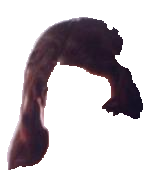

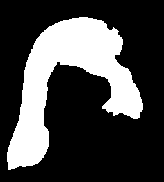

celeba_full_hair_000001 train female high 1.0


In [6]:
def show_asset(metadata: dict[str, object]):
    with Image.open(metadata['image_path']).convert('RGBA') as image:
        display(image)
    with Image.open(metadata['mask_path']).convert('L') as mask:
        display(mask)
    print(
        metadata['asset_id'],
        metadata['partition'],
        metadata['gender_label'],
        metadata['confidence_bucket'],
        metadata.get('full_hair_score'),
    )

if created_assets:
    show_asset(created_assets[0])


In [7]:
rows = []
for metadata in created_assets[:25]:
    rows.append({
        'asset_id': metadata['asset_id'],
        'partition': metadata['partition'],
        'gender_label': metadata['gender_label'],
        'confidence_bucket': metadata['confidence_bucket'],
        'quality_score': metadata['quality_score'],
        'full_hair_score': metadata.get('full_hair_score'),
        'color_hint': metadata['celeba_attribute_hints']['color_hint'],
        'texture_hint': metadata['celeba_attribute_hints']['texture_hint'],
        'bangs_hint': metadata['celeba_attribute_hints']['bangs_hint'],
    })

pd.DataFrame(rows)


,asset_id,partition,gender_label,confidence_bucket,quality_score,full_hair_score,color_hint,texture_hint,bangs_hint
0,celeba_full_hair_000001,train,female,high,1.0,1.00,Black_Hair,NaN,False
1,celeba_full_hair_000002,train,male,medium,1.0,0.85,Brown_Hair,Straight_Hair,False
2,celeba_full_hair_000003,train,female,high,1.0,1.00,NaN,Straight_Hair,False
3,celeba_full_hair_000004,train,male,high,1.0,1.00,Black_Hair,Straight_Hair,False
4,celeba_full_hair_000005,train,female,high,1.0,1.00,Black_Hair,NaN,False
5,celeba_full_hair_000006,train,male,high,1.0,1.00,NaN,NaN,True
6,celeba_full_hair_000007,train,male,high,1.0,1.00,Black_Hair,Wavy_Hair,False
7,celeba_full_hair_000008,train,male,high,1.0,1.00,Black_Hair,Straight_Hair,False
8,celeba_full_hair_000009,train,male,high,1.0,1.00,Black_Hair,Straight_Hair,False
9,celeba_full_hair_000010,train,male,high,1.0,1.00,Black_Hair,NaN,False
